<a href="https://colab.research.google.com/github/sebastianquintanam/dataexperience-final-project/blob/main/notebooks/Etapa3_Visualizacion_y_Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final DataXperience
## Etapa 3: Visualización, modelo predictivo y storytelling

**Hecho por:** Andres Sebastian Quintana Morales

En esta última etapa contamos la historia que salió de los datos, armamos un modelo que
predice el precio de un portátil a partir de sus características, y planteamos para qué
sirve todo esto en la práctica.

## 3.1 Cargamos los datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")

df = pd.read_csv('laptop_price_limpio.csv')
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1303, 18)


,Company,TypeName,Inches,Ram_GB,Weight_kg,Touchscreen,IPS,Res_X,Res_Y,PPI,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Cpu_gama,Gpu_marca,SO,Price_euros
0,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,128.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1339.69
1,Apple,Ultrabook,13.3,8,1.34,0,0,1440,900,127.677940,0.0,0.0,128.0,0.0,Intel Core i5,Intel,Mac,898.94
2,HP,Notebook,15.6,8,1.86,0,0,1920,1080,141.211998,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Otro,575.00
3,Apple,Ultrabook,15.4,16,1.83,0,1,2880,1800,220.534624,512.0,0.0,0.0,0.0,Intel Core i7,AMD,Mac,2537.45
4,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1803.60


---
# PARTE 1: La historia que cuentan los datos

## 3.2 El punto de partida

La pregunta era: ¿qué hace que un portátil sea caro?

La respuesta intuitiva sería el tamaño o la marca. Pero los datos dicen otra cosa.

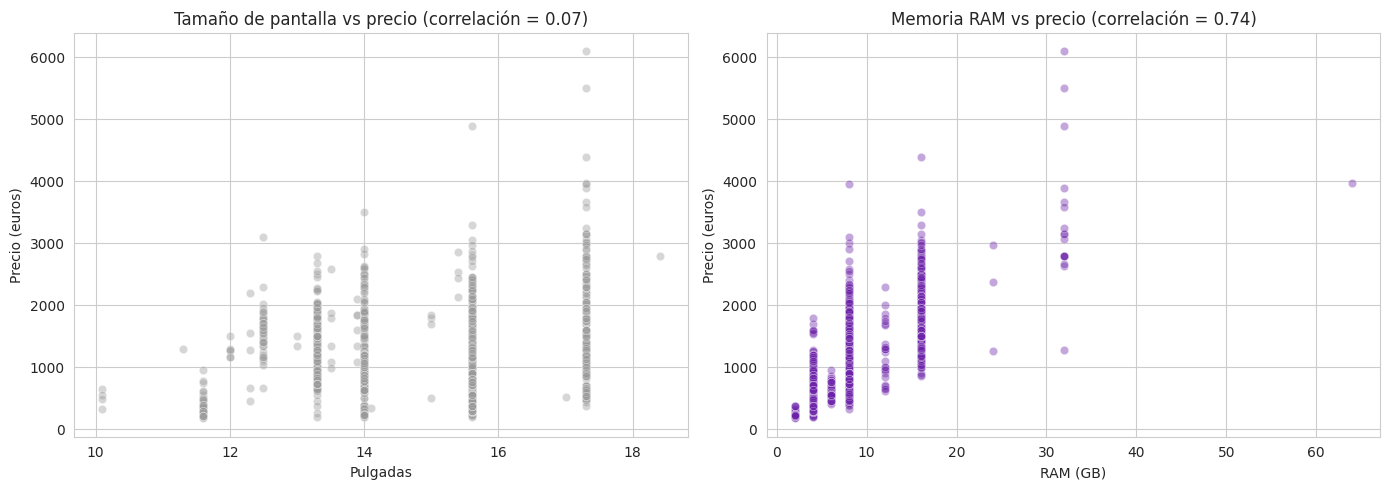

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# lo que uno pensaría que importa
sns.scatterplot(x='Inches', y='Price_euros', data=df, alpha=0.4, ax=axes[0], color='#999999')
axes[0].set_title(f'Tamaño de pantalla vs precio (correlación = {df.Inches.corr(df.Price_euros):.2f})')
axes[0].set_xlabel('Pulgadas')
axes[0].set_ylabel('Precio (euros)')

# lo que realmente importa
sns.scatterplot(x='Ram_GB', y='Price_euros', data=df, alpha=0.4, ax=axes[1], color='#6B21A8')
axes[1].set_title(f'Memoria RAM vs precio (correlación = {df.Ram_GB.corr(df.Price_euros):.2f})')
axes[1].set_xlabel('RAM (GB)')
axes[1].set_ylabel('Precio (euros)')

plt.tight_layout()
plt.show()

**El tamaño no dice nada.** La nube de puntos de la izquierda está completamente
dispersa: hay portátiles de 15.6 pulgadas que cuestan 300 euros y otros del mismo tamaño
que cuestan 4.000. La correlación es de apenas 0.07.

**La RAM sí.** A la derecha se ve una tendencia clara hacia arriba. La correlación es de
0.74, la más alta de todo el dataset.

Esto tiene sentido si uno lo piensa: el tamaño de la pantalla es una decisión de formato,
no de potencia. Un portátil grande puede ser barato porque es pesado y básico.

## 3.3 Lo que de verdad mueve el precio

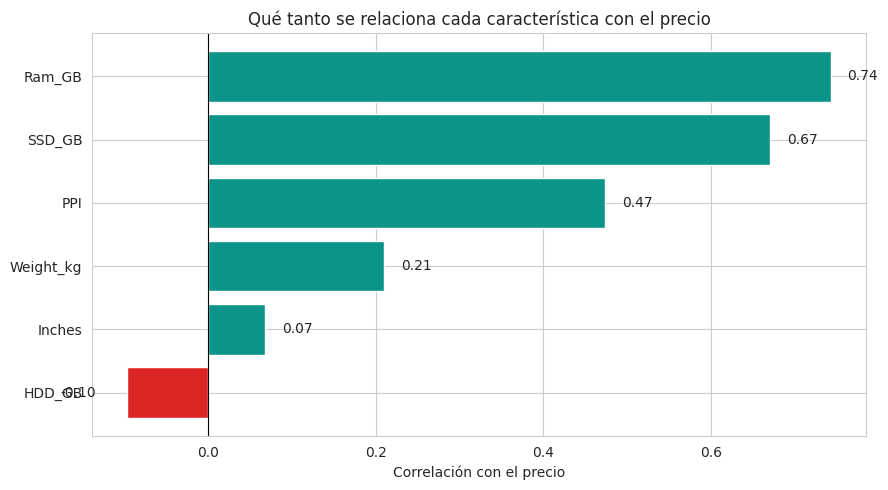

In [17]:
numericas = ['Ram_GB', 'SSD_GB', 'PPI', 'Weight_kg', 'Inches', 'HDD_GB']
corr = df[numericas + ['Price_euros']].corr()['Price_euros'].drop('Price_euros').sort_values()

plt.figure(figsize=(9, 5))
colores = ['#DC2626' if v < 0 else '#0D9488' for v in corr.values]
plt.barh(corr.index, corr.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Qué tanto se relaciona cada característica con el precio')
plt.xlabel('Correlación con el precio')
for i, v in enumerate(corr.values):
    plt.text(v + (0.02 if v > 0 else -0.08), i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

Hay un dato que llama la atención: **el disco duro tiene correlación negativa**.

No es que un disco duro haga más barato al equipo. Es que los portátiles que todavía
traen HDD son los de gama de entrada, mientras que los caros vienen con SSD. La variable
está señalando el segmento, no causando el precio.

Es un buen recordatorio de que correlación no es causalidad.

## 3.4 Las gamas del mercado

Al agrupar por tipo de equipo aparece una segmentación bastante clara.

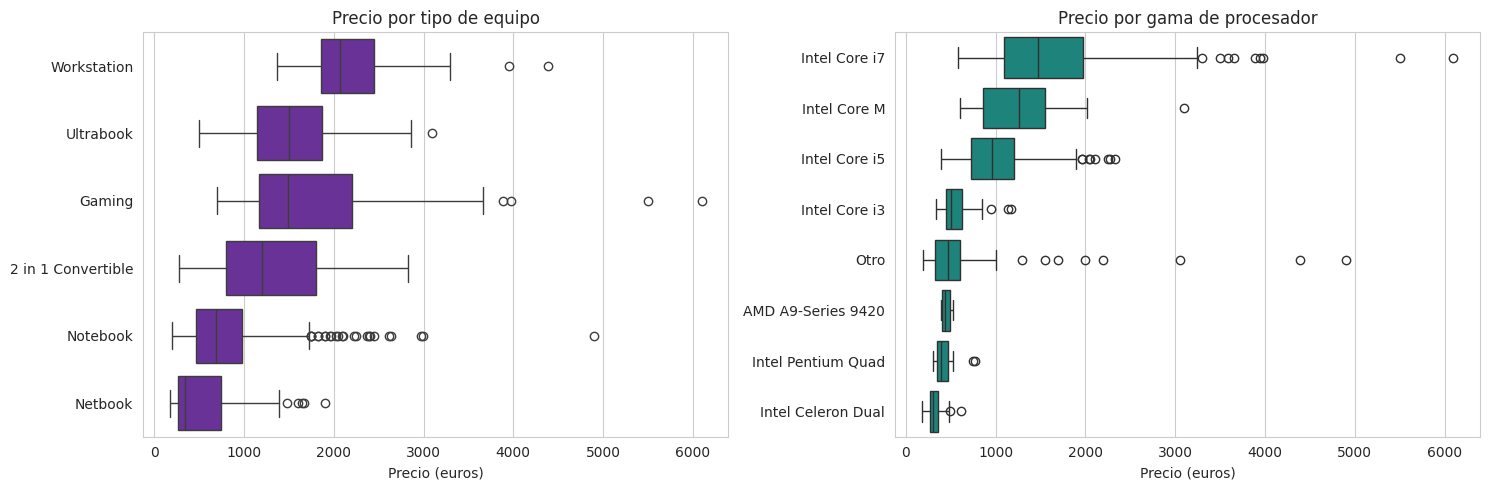

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

orden = df.groupby('TypeName')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='TypeName', data=df, order=orden, ax=axes[0], color='#6B21A8')
axes[0].set_title('Precio por tipo de equipo')
axes[0].set_xlabel('Precio (euros)')
axes[0].set_ylabel('')

orden_cpu = df.groupby('Cpu_gama')['Price_euros'].median().sort_values(ascending=False).index
sns.boxplot(x='Price_euros', y='Cpu_gama', data=df, order=orden_cpu, ax=axes[1], color='#0D9488')
axes[1].set_title('Precio por gama de procesador')
axes[1].set_xlabel('Precio (euros)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [6]:
resumen = df.groupby('TypeName')['Price_euros'].agg(['count', 'median']).sort_values('median', ascending=False)
resumen.columns = ['Equipos', 'Precio mediano']
print(resumen.round(0))

                    Equipos  Precio mediano
TypeName                                   
Workstation              29          2065.0
Ultrabook               196          1499.0
Gaming                  205          1493.0
2 in 1 Convertible      121          1199.0
Notebook                727           691.0
Netbook                  25           340.0


Las Workstation tienen una mediana de 2.065 euros y los Netbook de 340: seis veces de
diferencia. Y el procesador ordena el mercado casi perfecto, de i7 hacia abajo hasta los
Celeron.

Es decir, **el precio no depende de una sola cosa sino de un combo de características que
van juntas.** Un equipo con i7 normalmente también trae más RAM, SSD y mejor pantalla.
Por eso vale la pena construir un modelo que las considere todas al tiempo, en vez de
mirar variable por variable.

---
# PARTE 2: El modelo predictivo

## 3.5 Preparar los datos para el modelo

Acá hay un problema que resolver. Scikit-learn solo trabaja con números, pero varias de
nuestras variables son texto: la marca, el tipo de equipo, la gama del procesador.

No podemos simplemente asignarles números (Apple=1, Dell=2, HP=3) porque el modelo
interpretaría que HP es "mayor" que Apple, lo cual no significa nada.

La solución es el **one-hot encoding**: convertir cada categoría en su propia columna de
ceros y unos. Si un equipo es Ultrabook, la columna `TypeName_Ultrabook` vale 1 y todas
las demás columnas de tipo valen 0.

Usamos `drop_first=True` para eliminar una categoría de cada variable y evitar información
redundante: si un equipo no es ninguno de los otros tipos, ya sabemos cuál es.

In [8]:
numericas = ['Ram_GB', 'Weight_kg', 'Inches', 'PPI', 'SSD_GB', 'HDD_GB',
             'Flash_Storage_GB', 'Hybrid_GB', 'Touchscreen', 'IPS']
categoricas = ['Company', 'TypeName', 'Cpu_gama', 'Gpu_marca', 'SO']

X = pd.get_dummies(df[numericas + categoricas], columns=categoricas, drop_first=True)
y = df['Price_euros']

print("Columnas antes del encoding:", len(numericas + categoricas))
print("Columnas después del encoding:", X.shape[1])
print("\nEjemplo de columnas creadas:")
print([col for col in X.columns if col.startswith('TypeName_')])

Columnas antes del encoding: 15
Columnas después del encoding: 46

Ejemplo de columnas creadas:
['TypeName_Gaming', 'TypeName_Netbook', 'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation']


## 3.6 Dividir en entrenamiento y prueba

Separamos el 80% de los datos para entrenar y guardamos el 20% para probar. Esto es
importante: si evaluáramos el modelo con los mismos datos que usó para aprender, el
resultado sería mentiroso. Lo que queremos saber es qué tan bien predice equipos que
nunca ha visto.

El `random_state=42` es para que la división sea siempre la misma y cualquiera pueda
reproducir estos resultados.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Equipos para entrenar:", len(X_train))
print("Equipos para probar:  ", len(X_test))

Equipos para entrenar: 1042
Equipos para probar:   261


## 3.7 Entrenar el modelo

Usamos regresión lineal múltiple. La idea es encontrar cuánto suma o resta al precio cada
característica, y sumarlo todo.

In [10]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Modelo entrenado.")
print("Intercepto:", round(modelo.intercept_, 2))

Modelo entrenado.
Intercepto: -231.03


## 3.8 ¿Qué tan bien predice?

Evaluamos con tres métricas:

- **R²**: qué porcentaje de la variación del precio logra explicar el modelo. Va de 0 a 1.
- **MAE**: en promedio, cuántos euros se equivoca.
- **RMSE**: parecido al MAE pero castiga más los errores grandes.

In [11]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   = {r2:.3f}")
print(f"MAE  = {mae:.0f} euros")
print(f"RMSE = {rmse:.0f} euros")
print()
print(f"El modelo explica el {r2*100:.1f}% de la variación del precio.")
print(f"En promedio se equivoca en {mae:.0f} euros sobre un precio mediano de {y.median():.0f}.")

R²   = 0.766
MAE  = 234 euros
RMSE = 345 euros

El modelo explica el 76.6% de la variación del precio.
En promedio se equivoca en 234 euros sobre un precio mediano de 977.


In [12]:
# comparamos contra el rendimiento en entrenamiento para ver si hay sobreajuste
print(f"R² en entrenamiento: {modelo.score(X_train, y_train):.3f}")
print(f"R² en prueba:        {r2:.3f}")

R² en entrenamiento: 0.780
R² en prueba:        0.766


Los dos R² son parecidos (0.78 contra 0.77), o sea que el modelo **no está sobreajustado**.
Si hubiera aprendido de memoria los datos de entrenamiento, el R² de prueba sería mucho
más bajo.

Un R² de 0.77 significa que las características técnicas explican tres cuartas partes de
la variación del precio. El cuarto restante son cosas que el dataset no captura: el
prestigio de la marca, el diseño, promociones, el momento en que se tomó el precio.

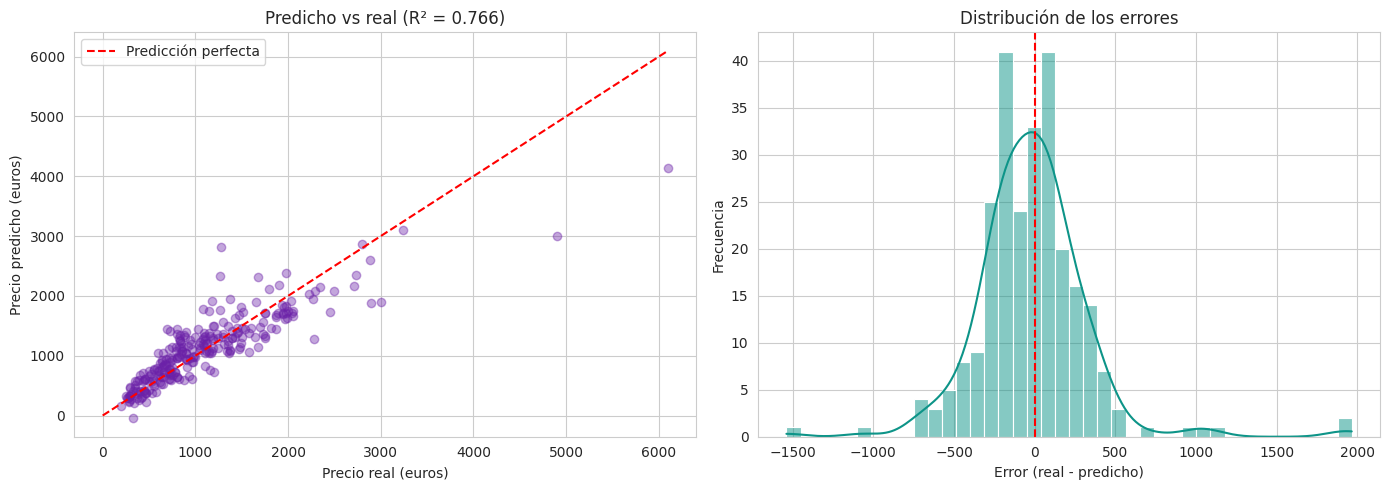

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicho vs real
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#6B21A8')
lim = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, 'r--', label='Predicción perfecta')
axes[0].set_xlabel('Precio real (euros)')
axes[0].set_ylabel('Precio predicho (euros)')
axes[0].set_title(f'Predicho vs real (R² = {r2:.3f})')
axes[0].legend()

# distribución de los errores
errores = y_test - y_pred
sns.histplot(errores, bins=40, kde=True, ax=axes[1], color='#0D9488')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Error (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de los errores')

plt.tight_layout()
plt.show()

En el gráfico de la izquierda, mientras más pegados estén los puntos a la línea roja,
mejor predice. Se ve que funciona bien en el rango de 500 a 2.000 euros, donde está la
mayoría del catálogo, y se dispersa en los equipos muy caros: hay pocos de esos y el
modelo tuvo menos con qué aprender.

Los errores están centrados en cero, que es lo que uno quiere: el modelo no se equivoca
sistemáticamente hacia arriba ni hacia abajo.

## 3.9 Qué aprendió el modelo

Los coeficientes dicen cuánto suma o resta cada característica al precio, manteniendo
todo lo demás igual.

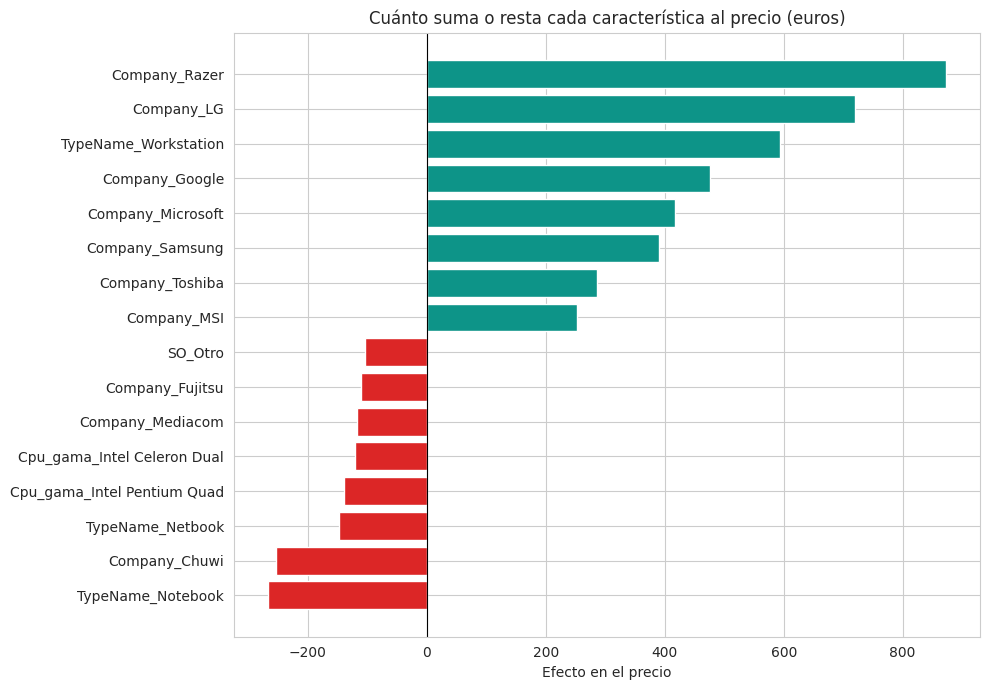

In [14]:
coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values()

top = pd.concat([coeficientes.head(8), coeficientes.tail(8)])

plt.figure(figsize=(10, 7))
colores = ['#DC2626' if v < 0 else '#0D9488' for v in top.values]
plt.barh(top.index, top.values, color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Cuánto suma o resta cada característica al precio (euros)')
plt.xlabel('Efecto en el precio')
plt.tight_layout()
plt.show()

In [15]:
print("--- Lo que más encarece ---")
print(coeficientes.tail(6).round(0).to_string())
print("\n--- Lo que más abarata ---")
print(coeficientes.head(6).round(0).to_string())
print("\n--- Efecto de las numéricas ---")
for v in ['Ram_GB', 'SSD_GB', 'PPI', 'Weight_kg']:
    print(f"{v:12s} {coeficientes[v]:+8.1f} euros por unidad")

--- Lo que más encarece ---
Company_Samsung         391.0
Company_Microsoft       417.0
Company_Google          476.0
TypeName_Workstation    594.0
Company_LG              719.0
Company_Razer           873.0

--- Lo que más abarata ---
TypeName_Notebook             -267.0
Company_Chuwi                 -254.0
TypeName_Netbook              -148.0
Cpu_gama_Intel Pentium Quad   -139.0
Cpu_gama_Intel Celeron Dual   -121.0
Company_Mediacom              -117.0

--- Efecto de las numéricas ---
Ram_GB          +45.5 euros por unidad
SSD_GB           +0.7 euros por unidad
PPI              +2.4 euros por unidad
Weight_kg      +237.2 euros por unidad


Cada GB de RAM adicional suma unos euros al precio, cada GB de SSD también, y el PPI
tiene un efecto claro. Del lado de las marcas, Razer y LG son las que más encarecen
respecto a la marca base, y ser Workstation suma bastante.

Ojo con interpretar esto como causa. El modelo dice que los equipos Razer son más caros
en promedio una vez descontadas las demás características, no que ponerle el logo de
Razer a un portátil lo encarezca.

## 3.10 Probando el modelo con un caso concreto

Para que se entienda mejor, veamos qué predice para un equipo específico del conjunto
de prueba.

In [16]:
i = 5
equipo = X_test.iloc[[i]]
real = y_test.iloc[i]
predicho = modelo.predict(equipo)[0]

# recuperamos las características originales de ese equipo
idx = X_test.index[i]
print("Equipo:", df.loc[idx, 'Company'], "|", df.loc[idx, 'TypeName'])
print("RAM:", df.loc[idx, 'Ram_GB'], "GB | SSD:", df.loc[idx, 'SSD_GB'], "GB")
print("Procesador:", df.loc[idx, 'Cpu_gama'])
print()
print(f"Precio real:     {real:.0f} euros")
print(f"Precio predicho: {predicho:.0f} euros")
print(f"Diferencia:      {abs(real - predicho):.0f} euros")

Equipo: HP | 2 in 1 Convertible
RAM: 8 GB | SSD: 256.0 GB
Procesador: Intel Core i5

Precio real:     1399 euros
Precio predicho: 1295 euros
Diferencia:      104 euros


---
# PARTE 3: Conclusiones y aplicación

## 3.11 Qué encontramos

**1. Las características técnicas explican el 77% del precio.** No es todo, pero es la
mayor parte. Existe una lógica bastante consistente en cómo se fijan los precios en este
mercado.

**2. La RAM y el almacenamiento SSD son los que más pesan.** Fueron las correlaciones más
altas y también los coeficientes más consistentes del modelo.

**3. El tamaño de pantalla es irrelevante, la calidad no.** Las pulgadas tienen correlación
de 0.07 con el precio, pero el PPI tiene 0.47. Lo que se paga no es una pantalla grande
sino una pantalla buena.

**4. El mercado está segmentado en gamas claras.** De Netbook a Workstation hay seis veces
de diferencia en el precio mediano, y el procesador ordena el mercado casi perfectamente.

**5. El modelo se equivoca en promedio 234 euros.** Sobre un precio mediano de 977, es un
error de alrededor del 24%. Sirve para estimar rangos, no para poner precios exactos.

## 3.12 Para qué sirve esto en la práctica

Un modelo así tiene usos concretos en el área de tecnología:

**Compras corporativas.** Cuando una empresa cotiza equipos para su personal, este modelo
permite estimar cuánto debería costar un portátil con determinadas especificaciones. Si un
proveedor cotiza muy por encima de la predicción, hay margen para negociar. Si cotiza muy
por debajo, vale la pena revisar por qué.

**Detección de oportunidades.** Los equipos cuyo precio real está muy por debajo del
predicho son candidatos a ser buenas compras: tienen mejores especificaciones de lo que su
precio sugiere.

**Definición de presupuestos.** En lugar de pedir un presupuesto genérico, se puede
justificar con datos: "un equipo con 16 GB de RAM y SSD de 512 para el área de desarrollo
debería costar alrededor de X euros".

**Lo que el modelo no puede hacer.** No sirve para predecir precios de equipos muy fuera
del rango del dataset, ni captura el efecto del tiempo (los precios de tecnología bajan),
ni incluye factores como garantía o servicio postventa, que en compras corporativas pesan
bastante.

## 3.13 Limitaciones

Para ser honestos con el alcance de este trabajo:

- El dataset es una foto de un momento, no una serie de tiempo. No sabemos de cuándo son
  los precios ni cómo han cambiado.
- La regresión lineal asume que las relaciones son lineales. Probablemente no lo son del
  todo: pasar de 4 a 8 GB de RAM no cuesta lo mismo que pasar de 32 a 64.
- Algunas categorías tienen muy pocos equipos (21 Mac, 12 con procesador AMD A9), así que
  sus coeficientes no son muy confiables.
- Los precios están en euros y corresponden a un mercado que no necesariamente se comporta
  igual que el colombiano.

## Resumen de la Etapa 3

Lo que hicimos:

- Visualizamos la relación entre las características y el precio, encontrando que la
  intuición sobre el tamaño de pantalla estaba equivocada
- Convertimos las variables categóricas a formato numérico con one-hot encoding, pasando
  de 15 a 46 columnas
- Entrenamos una regresión lineal múltiple con división 80/20
- Obtuvimos R² de 0.77 y error promedio de 234 euros, sin sobreajuste
- Interpretamos los coeficientes para entender qué aprendió el modelo
- Planteamos aplicaciones concretas y fuimos explícitos sobre las limitaciones